# DKAJ Visualization Demo (Framingham)

This notebook illustrates how to visualize **cluster-level** and **individual-level** explanations from a trained DKAJ model using artifacts saved by `experiments/run_dkaj.py`.

In [1]:
# --- Imports and global plotting style ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import AalenJohansenFitter
from sklearn.impute import SimpleImputer

import importlib
import visualization_utils
importlib.reload(visualization_utils)
from visualization_utils import transform, heatmap_plot

plt.style.use("seaborn-v0_8-muted")
sns.set_theme(style="white")

## 1. Configuration

Edit only this cell if you want to point to a different run.

In [2]:
# --- Run configuration (demo uses one dataset + one experiment run) ---
dataset = "framingham"
units = "days"

demo_output_dir = "./"
demo_visualization_dir = (
    "demo_visualization_data/"
)

# Files saved by experiments/run_dkaj.py for visualization
TRAIN_RAW_X_FNAME = "train_raw_input.npy"
TRAIN_LABELS_FNAME = "train_labels.npy"
DURATION_INDEX_FNAME = "duration_index.npy"
TRAIN_EMBEDDINGS_FNAME = "train_embeddings.npy"
EXEMPLAR_ASSIGNMENTS_FNAME = "exemplar_assignments.npy"

# NOTE: these two files are produced by a separate inference/export step on the test sets using a trained DKAJ model
TEST_WEIGHTS_FNAME = "demo_visualization_data/framingham_test_weights.npy"
TEST_PRED_CIF_FNAME = "demo_visualization_data/framingham_test_pred_cif.npy"

# Framingham competing risks mapping used in this demo:
# - labels[:,1] uses event coding where 0=censor, 1=Non-CVD death, 2=CVD death
EVENT_NONCVD = 1
EVENT_CVD = 2

# pred_cif_all_events (loaded below) uses risk axis indexing:
# - risk 0 = Non-CVD CIF
# - risk 1 = CVD CIF
RISK_NONCVD = 0
RISK_CVD = 1

# Visualization choices
N_CLUSTERS_TO_SHOW = 5       # number of clusters plotted in cluster-level section
N_TOP_CLUSTERS_FOR_TEST = 5  # number of clusters shown for individual explanation
TEST_INDEX = 3               # which test point to explain (0-based)

# Optional / expensive plot
PLOT_KERNEL_HEATMAP = True
KERNEL_HEATMAP_MAX_POINTS = 2000  # cap points for the similarity heatmap

## 2. Load saved artifacts

These are produced by `experiments/run_dkaj.py` under the run-specific `visualization_dir` (for the purpose of this demo, we put these under the directory `demo_visualization_data`).
- `train_raw_input.npy`: raw training covariates (before this notebook’s display-oriented transforms)
- `train_labels.npy`: two columns: observed time `Y`, event indicator `D`
- `duration_index.npy`: discrete time grid used by the model
- `train_embeddings.npy`: learned embedding per training sample
- `exemplar_assignments.npy`: list of clusters; each entry contains training indices belonging to that cluster


In [3]:
run_dir = os.path.join(demo_output_dir, demo_visualization_dir)

raw_features = np.load(os.path.join(run_dir, TRAIN_RAW_X_FNAME))
labels = np.load(os.path.join(run_dir, TRAIN_LABELS_FNAME))
duration_index = np.load(os.path.join(run_dir, DURATION_INDEX_FNAME))
embeddings = np.load(os.path.join(run_dir, TRAIN_EMBEDDINGS_FNAME))
exemplar_assignments = np.load(
    os.path.join(run_dir, EXEMPLAR_ASSIGNMENTS_FNAME),
    allow_pickle=True
)

n_train, d_raw = raw_features.shape
n_exemplars = len(exemplar_assignments)

print(f"raw_features: {raw_features.shape}")
print(f"labels:       {labels.shape}  (col0=time, col1=event)")
print(f"duration_index: {duration_index.shape}  (min={duration_index.min()}, max={duration_index.max()})")
print(f"embeddings:   {embeddings.shape}")
print(f"n_exemplars:  {n_exemplars}")

# cluster sizes
exemplar_sizes = np.array([len(exemplar_assignments[i]) for i in range(n_exemplars)], dtype=int)
print(f"cluster sizes: min={exemplar_sizes.min()}, median={np.median(exemplar_sizes):.0f}, max={exemplar_sizes.max()}")

raw_features: (2482, 18)
labels:       (2482, 2)  (col0=time, col1=event)
duration_index: (114,)  (min=0.0, max=8767.0)
embeddings:   (2482, 128)
n_exemplars:  160
cluster sizes: min=1, median=7, max=379


## 3. Feature transform used for visualization

`visualization_utils.transform()` converts the raw covariates into a one-hot/binned representation suitable for heatmaps.
This transform is for visualization only; it may differ from the model’s training preprocessing.


In [4]:
raw_features_imputed = np.zeros_like(raw_features)

# binary features
binary_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8]          # SEX ... PREVHYP
# categorical
categorical_indices = [9]                             # 'educ'
# continuous
continuous_indices = [10, 11, 12, 13, 14, 15, 16, 17] # TOTCHOL ... GLUCOSE

# 1. Impute binary features with most frequent (mode)
imputer_mode = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
raw_features_imputed[:, binary_indices] = imputer_mode.fit_transform(
    raw_features[:, binary_indices]
)

# 2. Impute categorical features (also mode)
for idx in categorical_indices:
    imputer_cat = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    raw_features_imputed[:, idx:idx+1] = imputer_cat.fit_transform(
        raw_features[:, idx:idx+1]
    )

# 3. Impute continuous features with mean
imputer_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
raw_features_imputed[:, continuous_indices] = imputer_mean.fit_transform(
    raw_features[:, continuous_indices]
)

transformed_features, transformed_feature_names, all_n_bins_to_use = transform(dataset, raw_features_imputed)
transformed_features = np.asarray(transformed_features)

print(f"transformed_features: {transformed_features.shape}")
print(f"num transformed_feature_names: {len(transformed_feature_names)}")

transformed_features: (2482, 51)
num transformed_feature_names: 51


/home/xiaobin/anaconda3/envs/conv_sota39/lib/python3.9/site-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/xiaobin/anaconda3/envs/conv_sota39/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## 4. (Optional) Kernel similarity heatmap among training points

This plot shows an kernel similarity between training embeddings.
It is purely illustrative and can be expensive for large `n_train`, so we cap to the first `KERNEL_HEATMAP_MAX_POINTS` points.


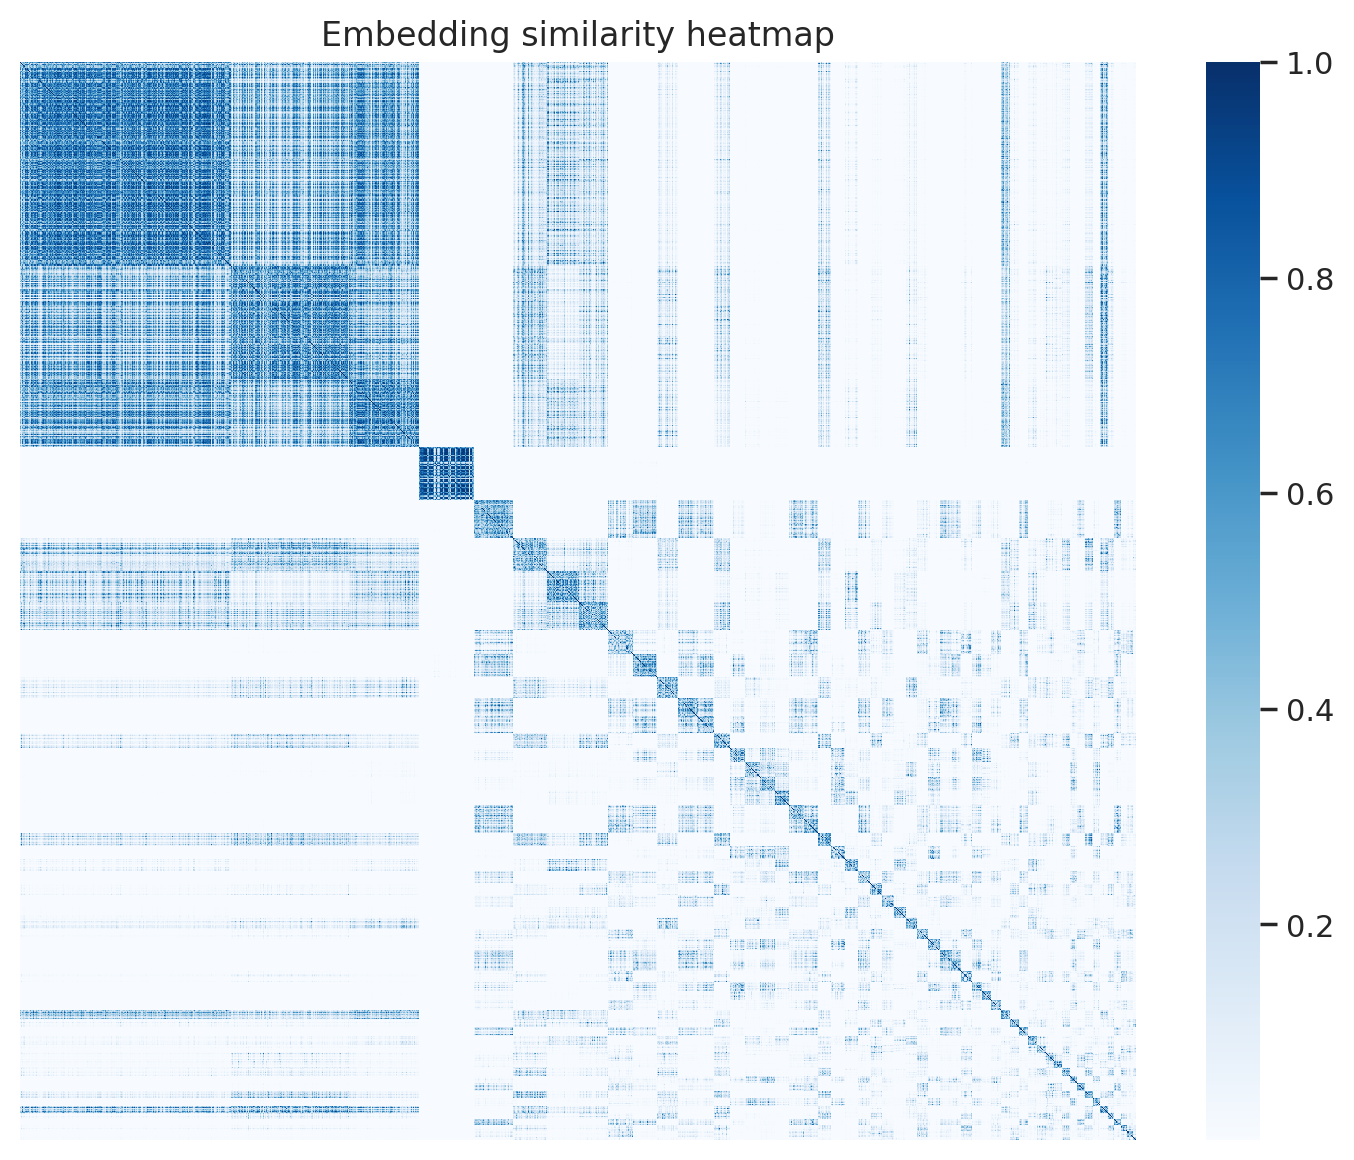

In [5]:
if PLOT_KERNEL_HEATMAP:
    import torch
    from models import symmetric_squared_pairwise_distances

    # Sort clusters by size and flatten their member indices (largest clusters first)
    sorted_exemplar_assignments = sorted(exemplar_assignments, key=lambda x: len(x), reverse=True)
    flattened = np.concatenate(sorted_exemplar_assignments).astype(int)

    # Cap points for computational convenience
    flattened = flattened[:KERNEL_HEATMAP_MAX_POINTS]
    E = torch.tensor(embeddings[flattened], dtype=torch.float32)

    kernel_matrix = torch.exp(-symmetric_squared_pairwise_distances(E)).cpu().numpy()

    plt.figure(figsize=(9, 7), dpi=200)
    ax = sns.heatmap(kernel_matrix, cmap="Blues", cbar=True, xticklabels=False, yticklabels=False)
    ax.set_title("Embedding similarity heatmap")
    plt.show()

## 5. Cluster-level CIFs (Aalen–Johansen within each cluster)

For each cluster, we fit an Aalen–Johansen estimator using the training samples assigned to that cluster.
We will use these curves for:
- cluster-level summaries
- individual explanations (showing which clusters contribute to a test point)


In [6]:
# Fit per-cluster AJ curves for each event of interest
aj_noncvd = []
aj_cvd = []
max_observed_times = np.zeros(n_exemplars, dtype=float)

for exemplar_idx in range(n_exemplars):
    observed_times, event_indicators = labels[exemplar_assignments[exemplar_idx]].T

    f_noncvd = AalenJohansenFitter()
    f_cvd = AalenJohansenFitter()

    f_noncvd.fit(observed_times, event_indicators, event_of_interest=EVENT_NONCVD)
    f_cvd.fit(observed_times, event_indicators, event_of_interest=EVENT_CVD)

    aj_noncvd.append(f_noncvd)
    aj_cvd.append(f_cvd)
    max_observed_times[exemplar_idx] = float(np.max(observed_times))

# CIF at max observed time within cluster (used for sorting / labeling)
cif_noncvd_at_max = np.array([aj_noncvd[i].cumulative_density_.values.flatten()[-1] for i in range(n_exemplars)])
cif_cvd_at_max = np.array([aj_cvd[i].cumulative_density_.values.flatten()[-1] for i in range(n_exemplars)])

## 6. Choose clusters to visualize

This demo visualizes the largest clusters, then orders them by their CVD CIF at the cluster’s maximum observed time.


In [7]:
# Step 1: take the largest clusters
largest_cluster_indices = np.argsort(-exemplar_sizes)

# Step 2: among the largest clusters, take N_CLUSTERS_TO_SHOW with highest CVD CIF at max time
candidate = largest_cluster_indices[:N_CLUSTERS_TO_SHOW]
top_clusters = candidate[np.argsort(-cif_cvd_at_max[candidate])[:N_CLUSTERS_TO_SHOW]]

# Step 3: order selected clusters by CVD CIF (descending) for display
exemplars_to_visualize = top_clusters[np.argsort(-cif_cvd_at_max[top_clusters])]

print("Selected clusters:")
for idx in exemplars_to_visualize:
    print(
        f"  cluster={idx:4d} | size={exemplar_sizes[idx]:4d} | "
        f"CIF_CVD(t_max)={cif_cvd_at_max[idx]:.3f} | CIF_nonCVD(t_max)={cif_noncvd_at_max[idx]:.3f} | "
        f"t_max={max_observed_times[idx]:.1f} {units}"
    )

Selected clusters:
  cluster=  14 | size=  98 | CIF_CVD(t_max)=0.888 | CIF_nonCVD(t_max)=0.102 | t_max=8767.0 days
  cluster=   7 | size=  70 | CIF_CVD(t_max)=0.557 | CIF_nonCVD(t_max)=0.257 | t_max=8767.0 days
  cluster=   0 | size= 126 | CIF_CVD(t_max)=0.079 | CIF_nonCVD(t_max)=0.103 | t_max=8767.0 days
  cluster=  10 | size= 210 | CIF_CVD(t_max)=0.067 | CIF_nonCVD(t_max)=0.071 | t_max=8767.0 days
  cluster=   1 | size= 379 | CIF_CVD(t_max)=0.037 | CIF_nonCVD(t_max)=0.061 | t_max=8767.0 days


## 7. Cluster characterization via feature heatmap

Each column is a selected cluster. Each row is a binned/one-hot feature.
Cell values are the mean of the indicator within the cluster (i.e., empirical proportion).


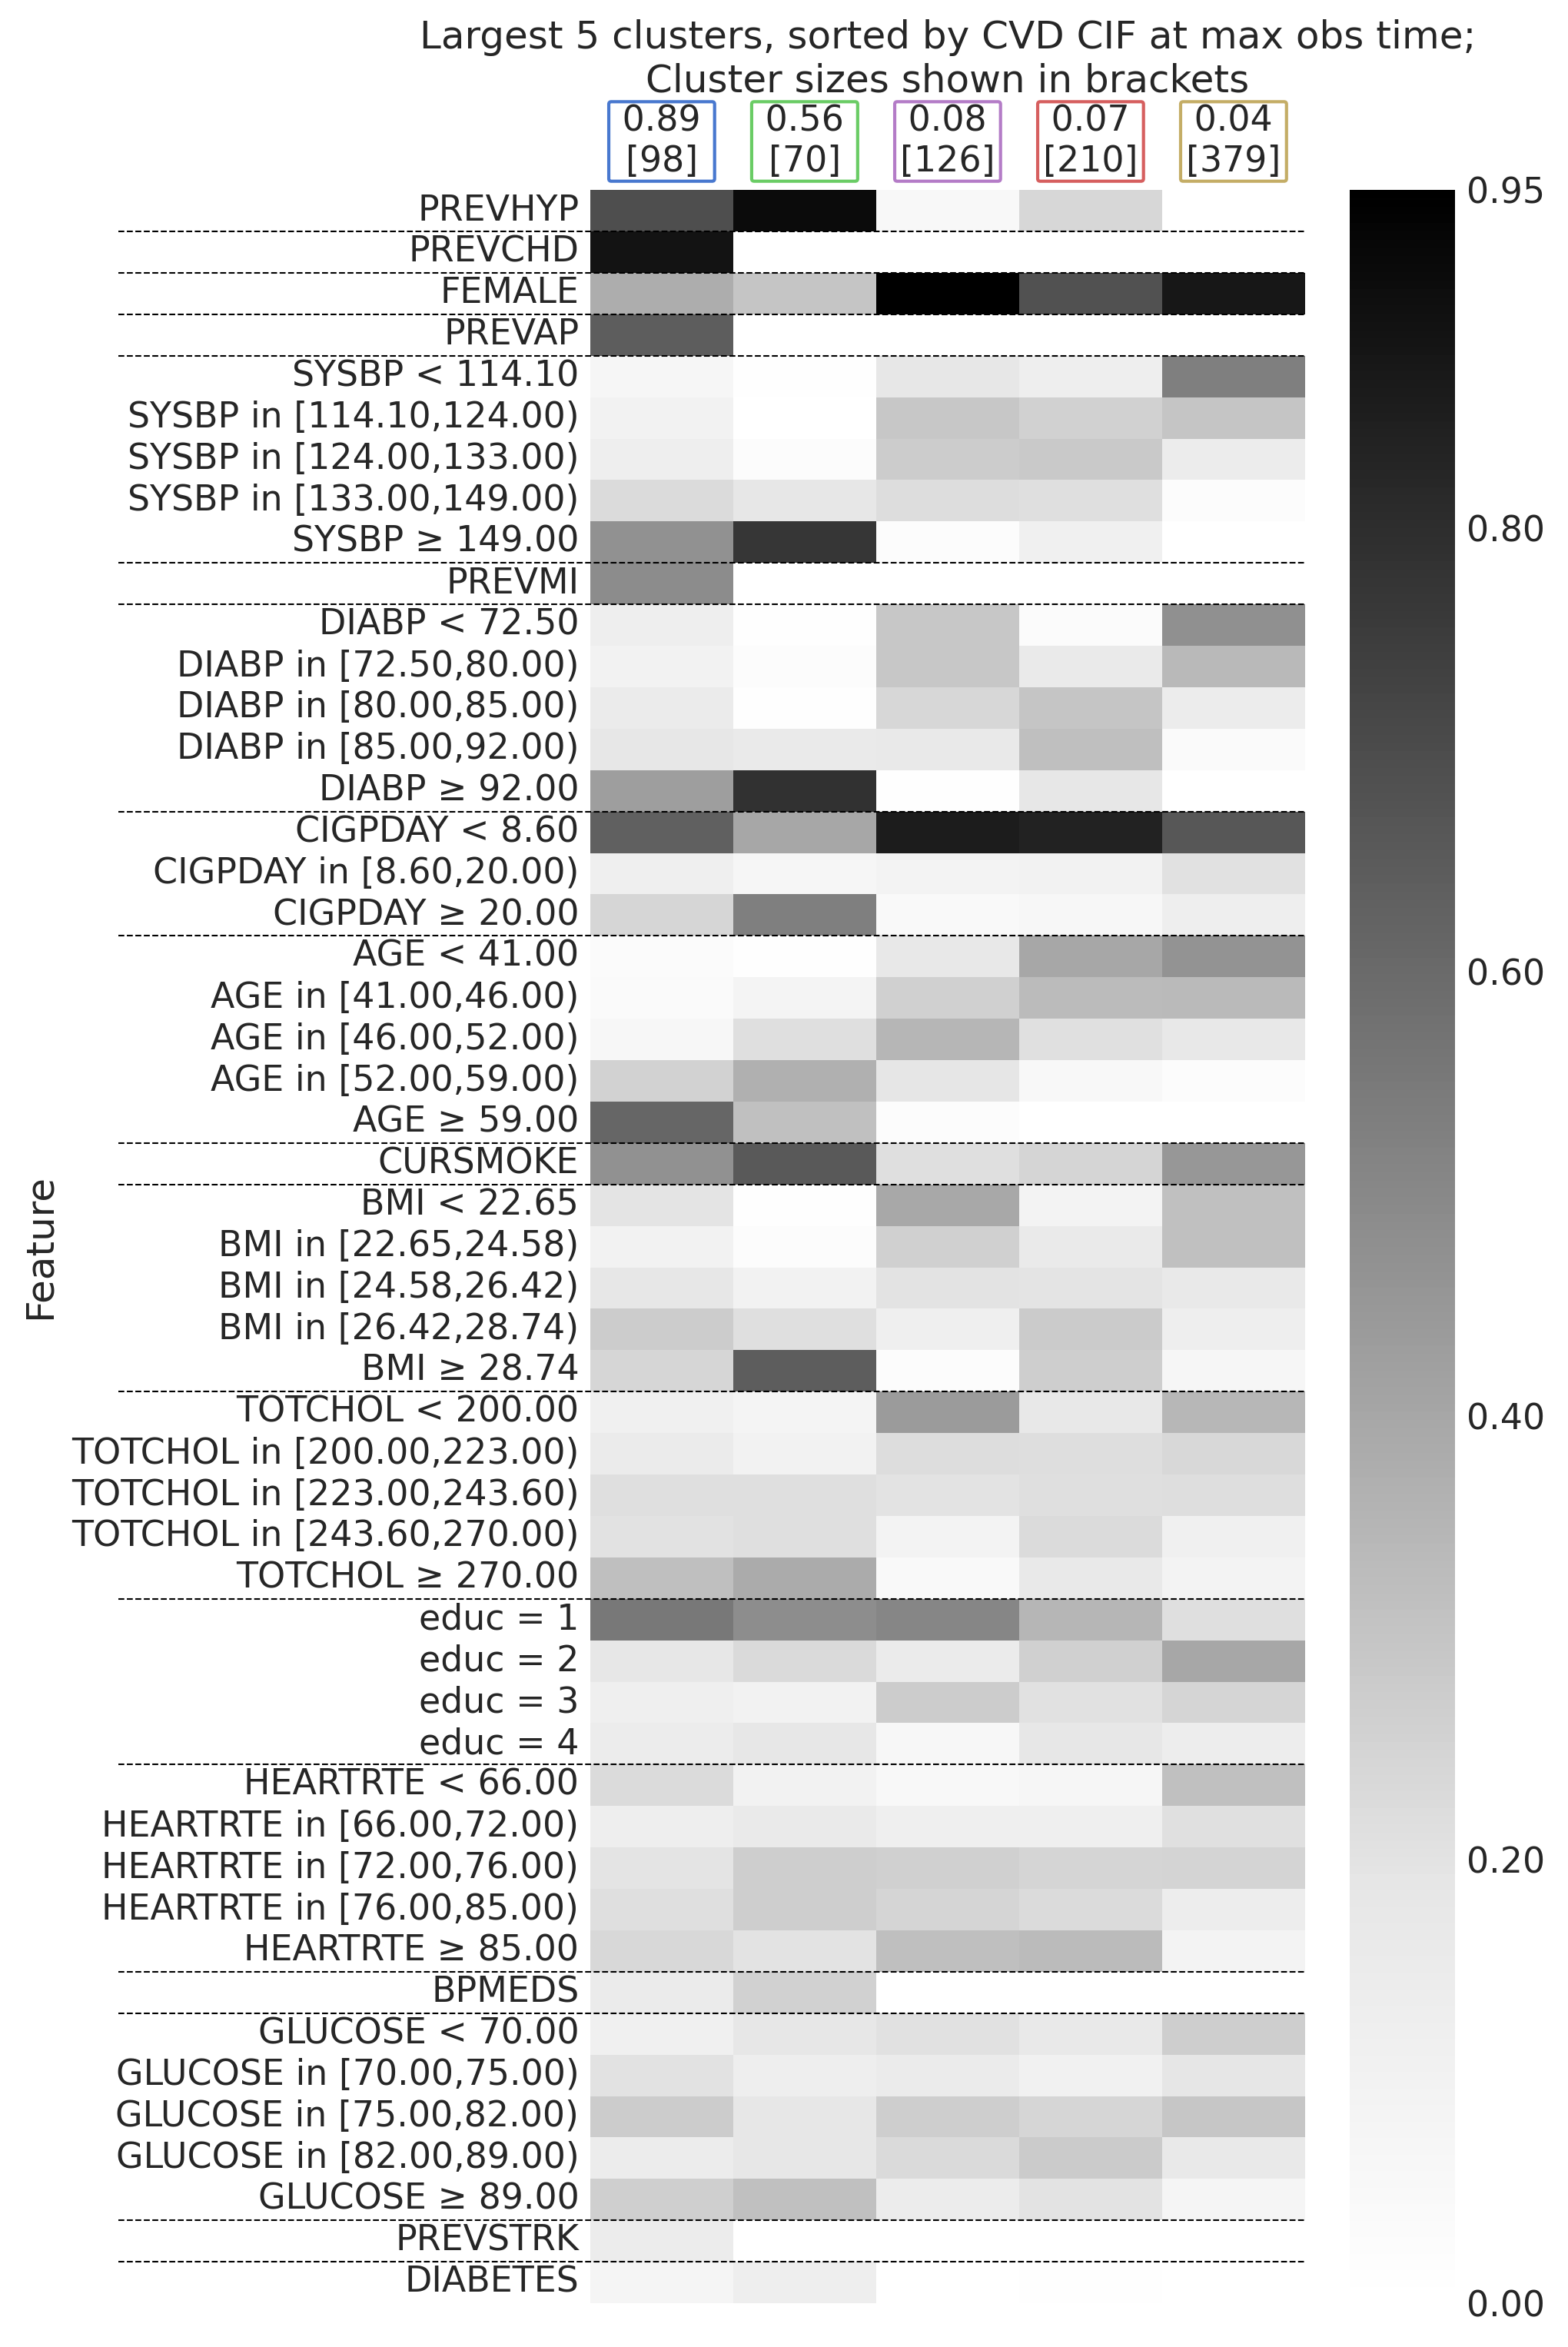

In [8]:
colors = ['#4878CF', '#6ACC65',  '#B47CC7', '#D65F5F', '#C4AD66', '#77BEDB',
          '#FFA500', '#8B4513', '#708090', '#FF69B4']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

# Map each training point -> its cluster id (for fast masking)
train_cluster_id = np.full(n_train, fill_value=-1, dtype=int)
for cid, members in enumerate(exemplar_assignments):
    train_cluster_id[np.asarray(members, dtype=int)] = cid

# Build heatmap: (n_transformed_features, n_selected_clusters)
heatmap = np.zeros((len(transformed_feature_names), len(exemplars_to_visualize)))
for col, cid in enumerate(exemplars_to_visualize):
    mask = (train_cluster_id == cid)
    heatmap[:, col] = transformed_features[mask].mean(axis=0)

# Use CVD CIF at max observed time only as a label vector (not for sorting inside heatmap_plot)
cif_label_vec = cif_cvd_at_max[exemplars_to_visualize]
cluster_sizes_vec = exemplar_sizes[exemplars_to_visualize]
max_times_vec = max_observed_times[exemplars_to_visualize]

heatmap_plot(
    heatmap=heatmap,
    cif_max_time=cif_label_vec,
    feature_names=transformed_feature_names,
    all_n_bins_to_use=all_n_bins_to_use,
    max_observed_times=max_times_vec,
    units=units,
    custom_xlabel=(
        f"Largest {N_CLUSTERS_TO_SHOW} clusters, sorted by CVD CIF at max obs time;\n"
        f"Cluster sizes shown in brackets"
    ),
    cluster_sizes=cluster_sizes_vec,
    axhline_xmin=-0.66,
    show_plot=True
)

ax = plt.gca()
muted_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for ticklabel, color in zip(ax.get_xticklabels(), muted_colors):
    ticklabel.set_bbox({'boxstyle': 'round', 'fill': False, 'edgecolor': color, 'linewidth': 1, 'pad': 0.07})
plt.show()

## 8. Cluster-level CIF curves

Left: CVD death (event 2). Right: Non-CVD death (event 1).
Legend entries show `CIF(t_max)` for each cluster.


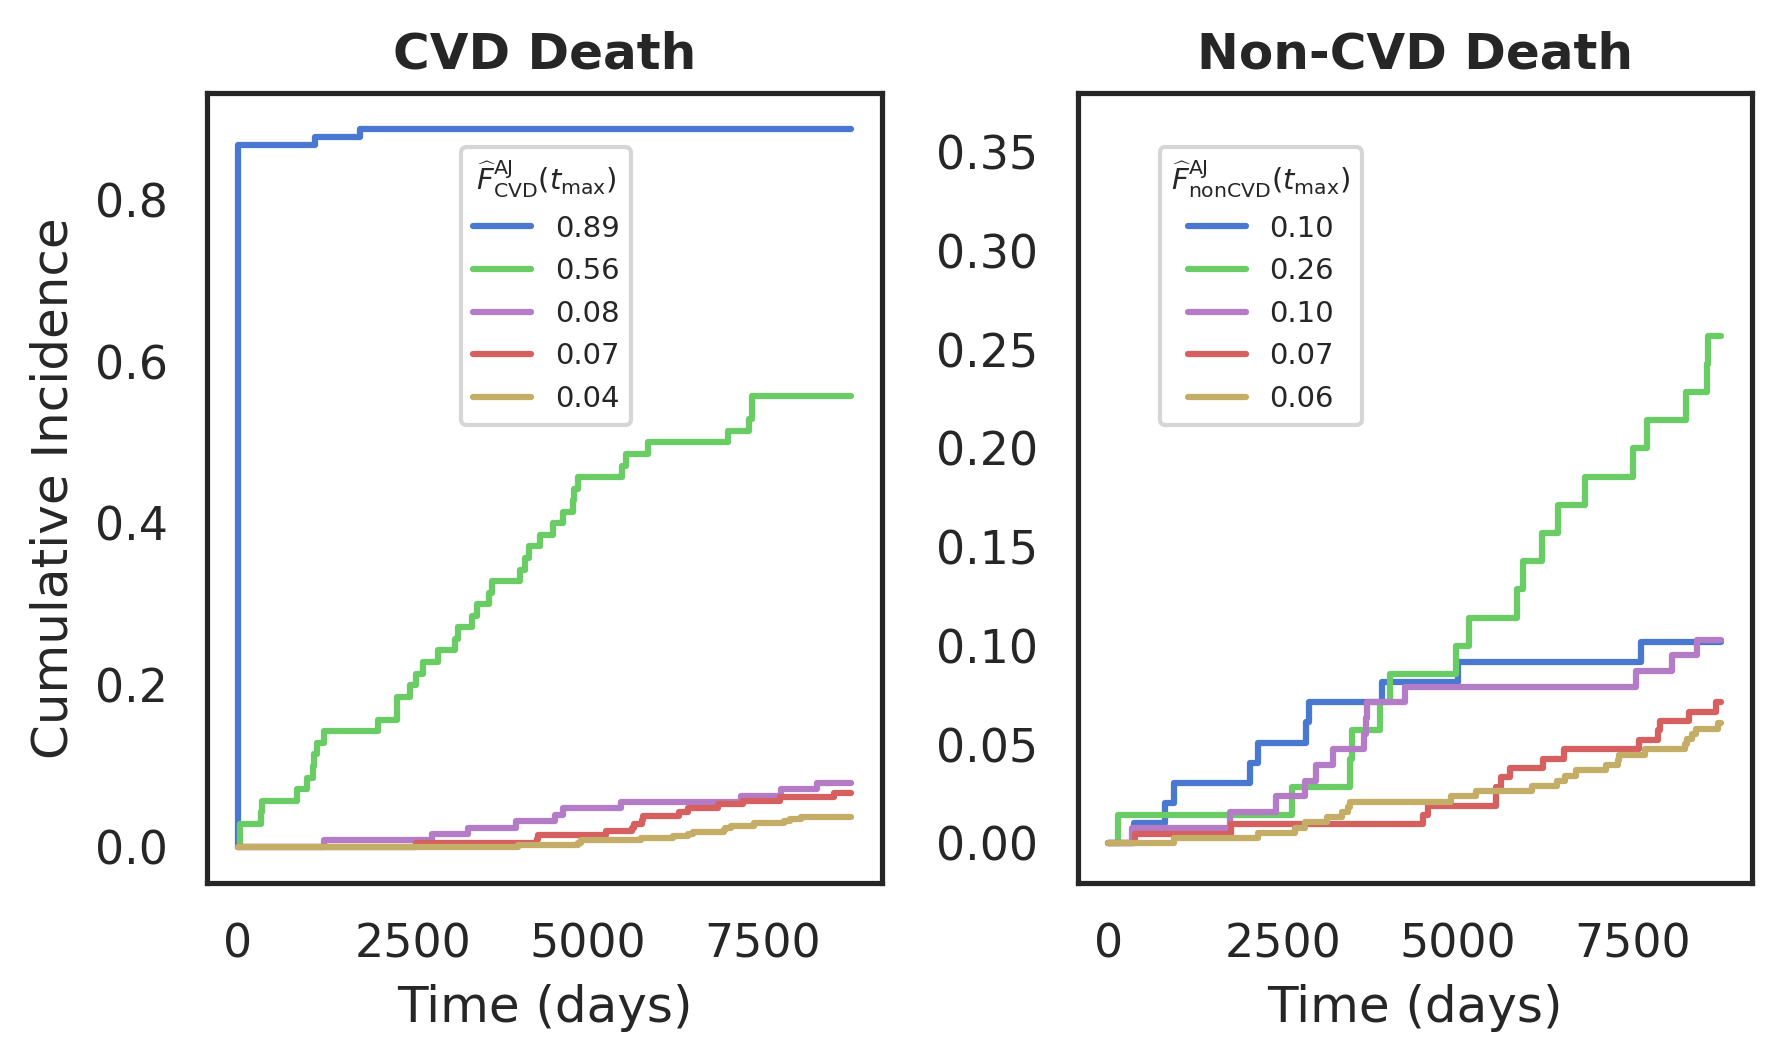

In [9]:
colors = ['#4878CF', '#6ACC65', '#B47CC7', '#D65F5F', '#C4AD66', '#77BEDB',
          '#FFA500', '#8B4513', '#708090', '#FF69B4']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

fig, axes = plt.subplots(1, 2, figsize=(6.1, 3.7), dpi=300)

for cid in exemplars_to_visualize:
    # axes[0].plot([], [])  # keep color cycle aligned
    aj_cvd[cid].plot(ax=axes[0], label=f"{cif_cvd_at_max[cid]:.2f}", ci_show=False)
    aj_noncvd[cid].plot(ax=axes[1], label=f"{cif_noncvd_at_max[cid]:.2f}", ci_show=False)

axes[0].set_xlabel('Time (%s)' % units)
axes[0].set_title('CVD Death', fontsize=12, weight="bold")
axes[0].set_ylabel("Cumulative Incidence")
axes[0].legend(title=r'$\widehat{F}_{\mathrm{CVD}}^{\mathrm{AJ}}(t_{\mathrm{max}})$', 
               title_fontsize=7,
               loc="upper right", bbox_to_anchor=(0.65, 0.95), frameon=True, fontsize=7)
axes[1].set_xlabel('Time (%s)' % units)
axes[1].set_title('Non-CVD Death', fontsize=12, weight="bold")
axes[1].legend(title=r'$\widehat{F}_{\mathrm{nonCVD}}^{\mathrm{AJ}}(t_{\mathrm{max}})$', 
               title_fontsize=7,
               loc="upper left", bbox_to_anchor=(0.1, 0.95), frameon=True, fontsize=7)
axes[1].set_ylim(-0.02, 0.38)

plt.tight_layout()
plt.show()

## 9. Individual-level explanation for one test point

We load:
- `test_weights`: cluster weights for each test point (one row per test sample)
- `test_pred_cif`: predicted CIF for each event and time for each test sample

We then:
1) normalize weights to sum to 1,
2) pick one test sample,
3) show top contributing clusters,
4) overlay the test sample’s predicted CIF with the top clusters’ AJ curves.


In [10]:
# --- Load test-time artifacts (produced by a separate inference/export step in this project) ---
if not (os.path.exists(TEST_WEIGHTS_FNAME) and os.path.exists(TEST_PRED_CIF_FNAME)):
    print("Missing test-time visualization files:")
    print(f"  - {TEST_WEIGHTS_FNAME}")
    print(f"  - {TEST_PRED_CIF_FNAME}")
    print("Skipping individual-level visualization section.")
    weights = None
    pred_cif_all_events = None
else:
    weights = np.load(TEST_WEIGHTS_FNAME)
    pred_cif_all_events = np.load(TEST_PRED_CIF_FNAME)

    print(f"weights: {weights.shape}  (n_test, n_exemplars)")
    print(f"pred_cif_all_events: {pred_cif_all_events.shape}  (n_risks, n_times, n_test)")

    # Normalize weights (avoid division by zero)
    row_sums = weights.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    weights_norm = weights / row_sums

    test_idx = TEST_INDEX # or randomly select one: np.random.randint(0, weights_norm.shape[-1])
    w = weights_norm[test_idx]
    cif_test = pred_cif_all_events[:, :, test_idx]

    # Top contributing clusters
    order = np.argsort(-w)
    top_cluster_ids = order[:N_TOP_CLUSTERS_FOR_TEST]
    top_weights = w[top_cluster_ids]
    mass = top_weights.sum()

    print(f"Explaining test_idx={test_idx}")
    print(f"Top-{N_TOP_CLUSTERS_FOR_TEST} clusters carry {100*mass:.2f}% of total weight.")
    for rank, (cid, ww) in enumerate(zip(top_cluster_ids, top_weights), start=1):
        print(f"  #{rank}: cluster={cid:4d} | weight={ww:.4f} | size={exemplar_sizes[cid]:4d} | CIF_CVD(t_max)={cif_cvd_at_max[cid]:.3f}")

weights: (1331, 160)  (n_test, n_exemplars)
pred_cif_all_events: (2, 114, 1331)  (n_risks, n_times, n_test)
Explaining test_idx=3
Top-5 clusters carry 56.40% of total weight.
  #1: cluster=   0 | weight=0.1490 | size= 126 | CIF_CVD(t_max)=0.079
  #2: cluster=   1 | weight=0.1435 | size= 379 | CIF_CVD(t_max)=0.037
  #3: cluster=  11 | weight=0.0998 | size=  58 | CIF_CVD(t_max)=0.034
  #4: cluster=  35 | weight=0.0926 | size=  51 | CIF_CVD(t_max)=0.235
  #5: cluster= 136 | weight=0.0790 | size=  10 | CIF_CVD(t_max)=0.000


### Helper: robust 'half-of-final' time

We compute the time where CIF reaches half of its final value (a simple descriptive summary).


In [11]:
if weights is not None:
    def time_at_half_final(t, f):
        """Return the time where f(t) reaches 0.5 * f(T). Uses linear interpolation.
        Returns np.nan if f never increases or final value is 0.
        """
        t = np.asarray(t)
        f = np.asarray(f)
        if len(t) == 0 or len(f) == 0 or f[-1] <= 0:
            return np.nan
        target = 0.5 * f[-1]
        idxs = np.where(f >= target)[0]
        if len(idxs) == 0:
            return np.nan
        idx = idxs[0]
        if idx == 0:
            return float(t[0])
        t1, t2 = t[idx-1], t[idx]
        f1, f2 = f[idx-1], f[idx]
        if f2 == f1:
            return float(t2)
        return float(t1 + (target - f1) * (t2 - t1) / (f2 - f1))

    t_half_cvd = time_at_half_final(duration_index, cif_test[RISK_CVD])
    t_half_noncvd = time_at_half_final(duration_index, cif_test[RISK_NONCVD])
    print(f"Half-of-final CIF time: CVD={t_half_cvd:.1f} {units}, Non-CVD={t_half_noncvd:.1f} {units}")

Half-of-final CIF time: CVD=5775.6 days, Non-CVD=5124.3 days


### Individual-level CIF + top-cluster AJ overlays

- Black curve: the test sample’s predicted CIF.
- Colored curves: AJ CIFs computed within the top-weight clusters.


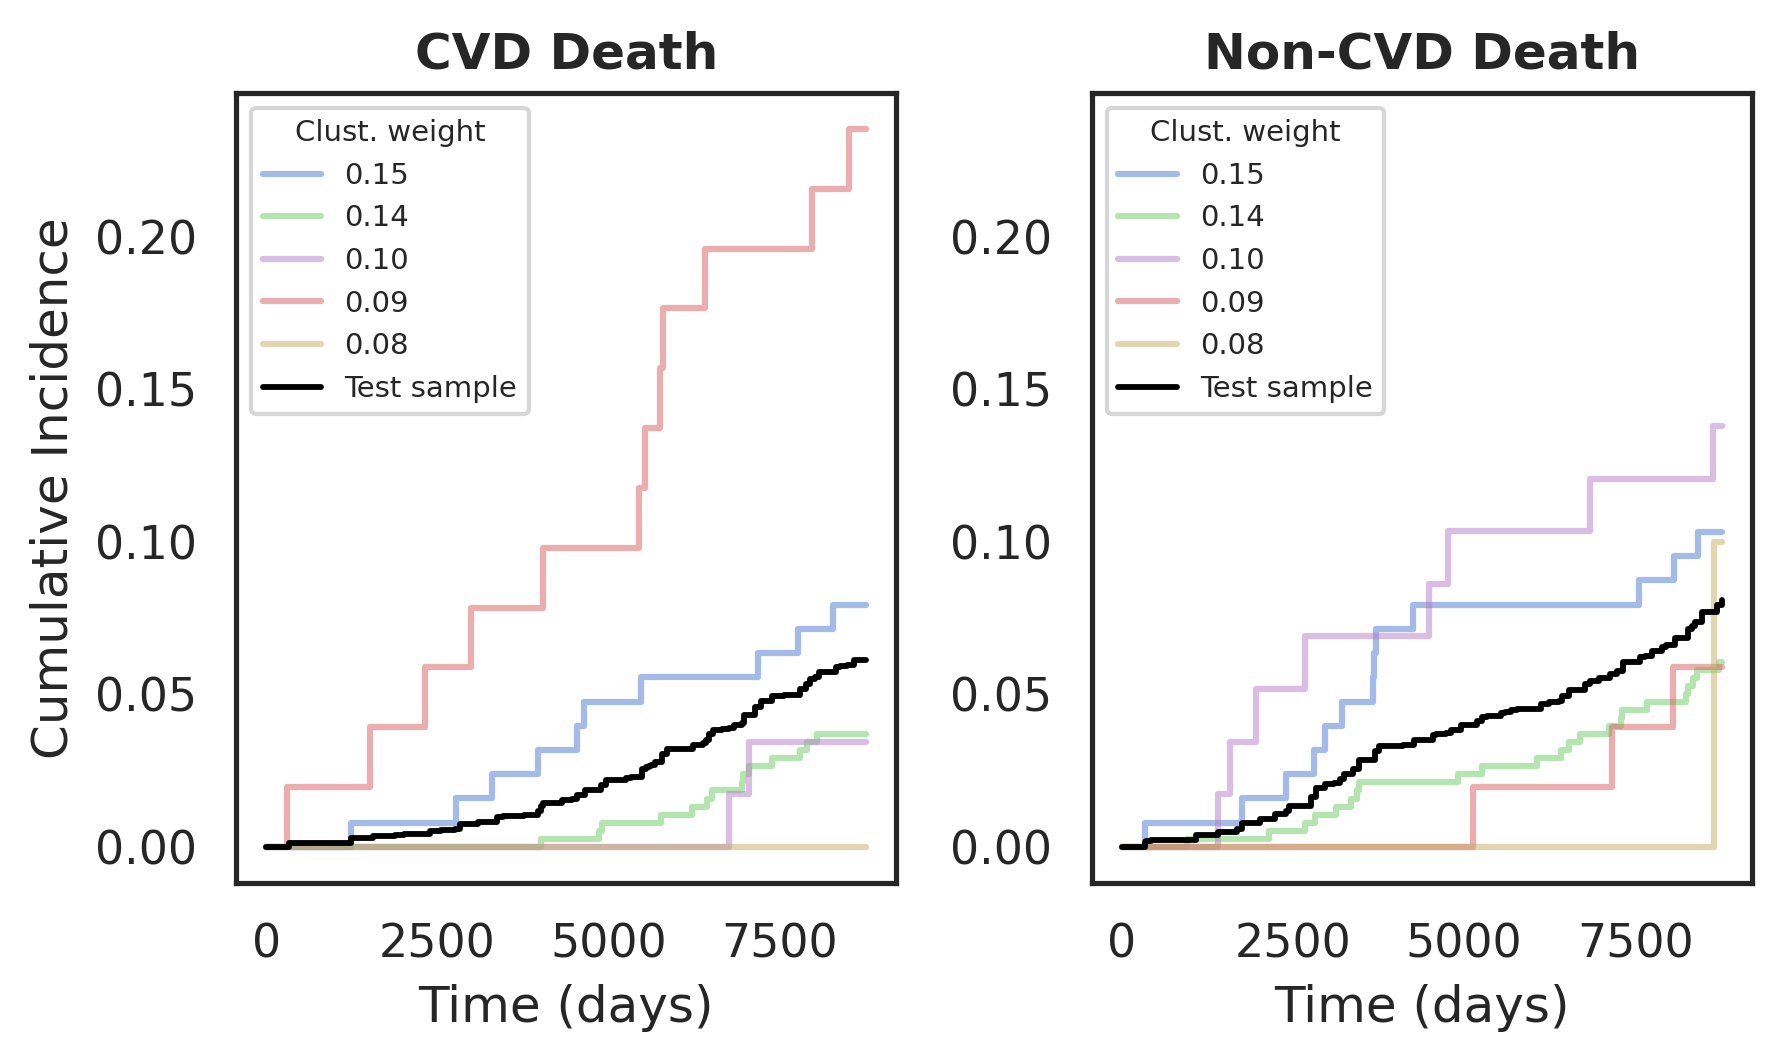

In [12]:
plt.style.use('seaborn-v0_8-muted')
if weights is not None:
    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

    fig, axes = plt.subplots(1, 2, figsize=(6.1, 3.7), dpi=300)

    # Overlay top cluster AJ curves
    for cid, ww in zip(top_cluster_ids, top_weights):
        aj_cvd[cid].plot(ax=axes[0], label=f"{ww:.2f}", ci_show=False, alpha=0.5)
        aj_noncvd[cid].plot(ax=axes[1], label=f"{ww:.2f}", ci_show=False, alpha=0.5)

    # Test sample predicted CIF (black)
    axes[0].step(duration_index, cif_test[RISK_CVD], where="post", color="black", linewidth=1.4, label="Test sample")
    axes[1].step(duration_index, cif_test[RISK_NONCVD], where="post", color="black", linewidth=1.4, label="Test sample")

    axes[0].set_xlabel(f'Time ({units})')
    axes[0].set_title('CVD Death', fontsize=12, weight="bold")
    axes[0].set_ylabel("Cumulative Incidence")
    axes[0].legend(title=r'Clust. weight', title_fontsize=7,
                loc="upper left", frameon=True, fontsize=7)
    axes[1].set_xlabel(f'Time ({units})')
    axes[1].set_title('Non-CVD Death', fontsize=12, weight="bold")
    axes[1].legend(title=r'Clust. weight', title_fontsize=7,
                loc="upper left", frameon=True, fontsize=7)
    if axes[0].get_ylim()[0] < axes[1].get_ylim()[1]:
        axes[1].set_ylim(axes[0].get_ylim())
    else:
        axes[0].set_ylim(axes[1].get_ylim())

    plt.tight_layout()
    plt.show()

### Individual-level cluster characterization heatmap

Same idea as the cluster-level heatmap, but columns are the top-weight clusters for the chosen test sample.


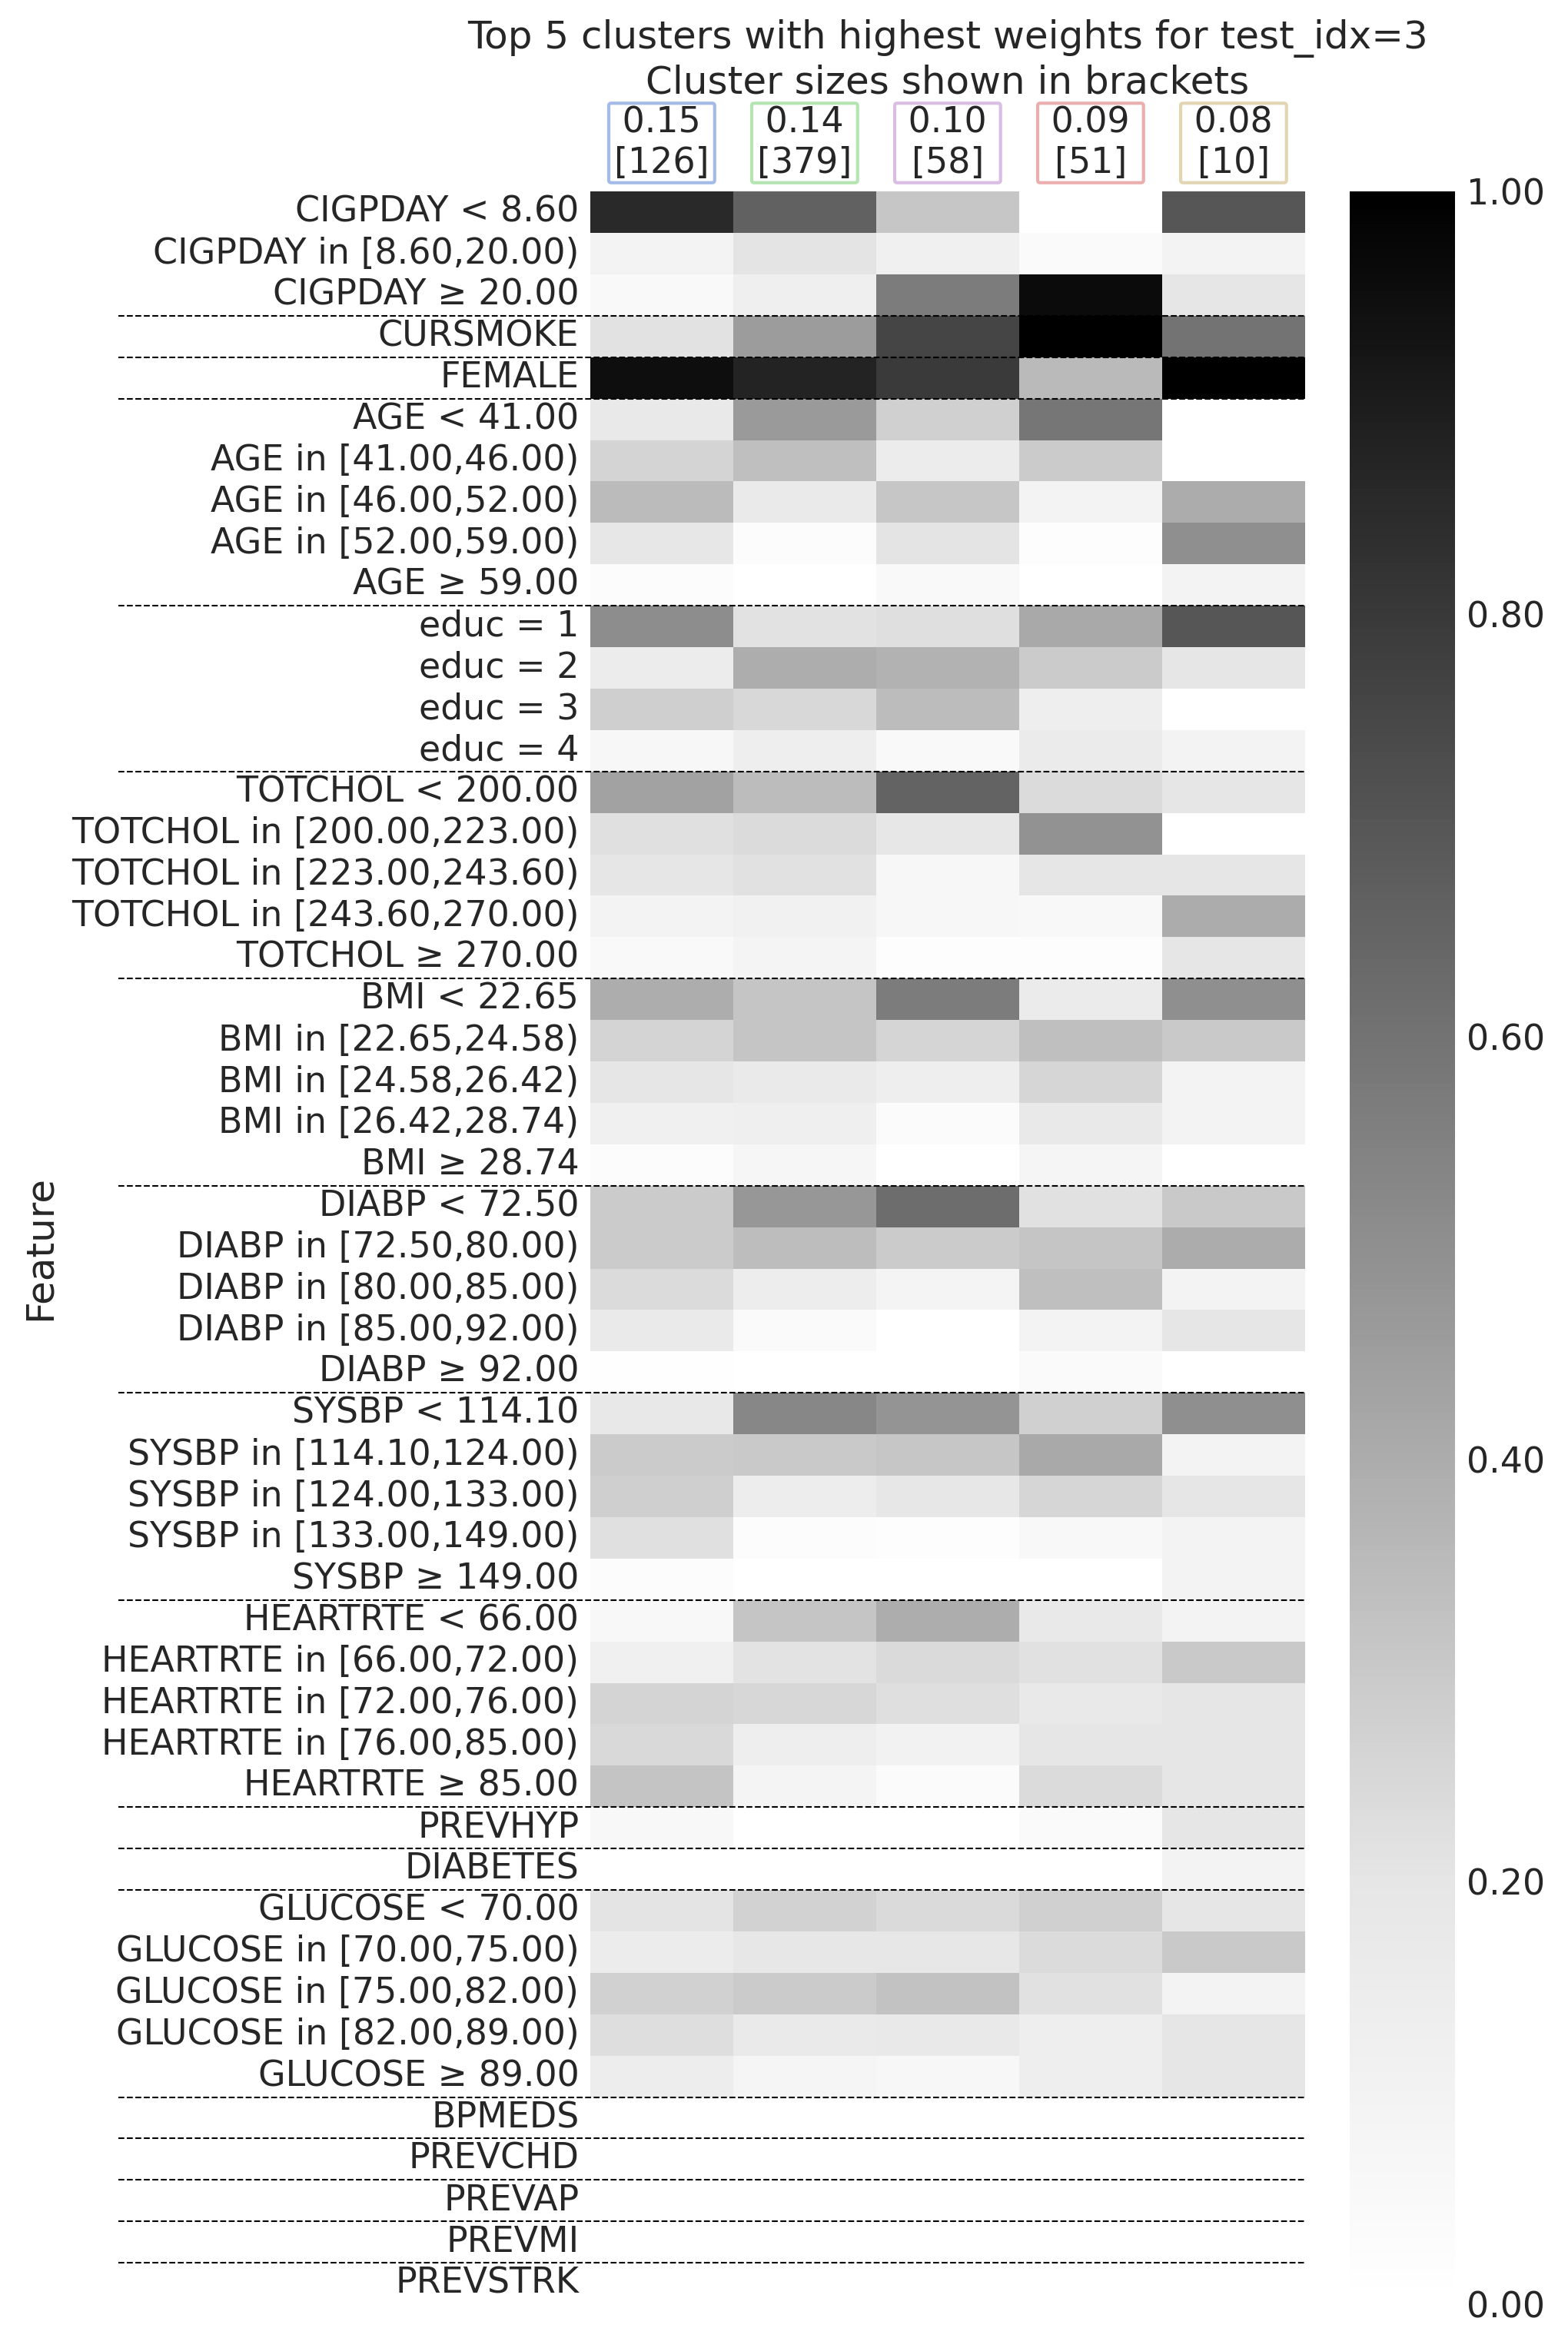

In [13]:
if weights is not None:
    heatmap_individual = np.zeros((len(transformed_feature_names), len(top_cluster_ids)))
    for col, cid in enumerate(top_cluster_ids):
        mask = (train_cluster_id == cid)
        heatmap_individual[:, col] = transformed_features[mask].mean(axis=0)

    heatmap_plot(
        heatmap=heatmap_individual,
        cif_max_time=top_weights,  # used for x-axis labeling
        feature_names=transformed_feature_names,
        all_n_bins_to_use=all_n_bins_to_use,
        max_observed_times=max_observed_times[top_cluster_ids],
        units=units,
        custom_xlabel=(
            f"Top {len(top_cluster_ids)} clusters with highest weights for test_idx={test_idx}\n"
            f"Cluster sizes shown in brackets"
        ),
        cluster_sizes=exemplar_sizes[top_cluster_ids],
        axhline_xmin=-0.66,
        show_plot=True
    )

    ax = plt.gca()
    muted_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for ticklabel, color in zip(ax.get_xticklabels(), muted_colors):
        ticklabel.set_bbox({
            'boxstyle': 'round',
            'fill': False,
            'edgecolor': color,
            'linewidth': 1,
            'pad': 0.07,
            'alpha': 0.5
        })
    plt.show()